# Water Vapor Absorption Coefficient Verification

Compute and plot the H2O line and continuum absorption cross-sections
$\sigma(\nu)$ [cm2 molecule-1] over 1-1000 GHz for a representative
mid-tropospheric atmospheric state.

| Parameter | Value |
|---|---|
| Pressure | 500 hPa |
| Temperature | 270 K |
| Precipitable water | 1 mm = 3.3 x 10^21 H2O cm-2 |
| Effective H2O layer | 10 km, uniform-density approximation |
| Local H2O density | 3.3 x 10^15 cm-3 |

The precipitable-water value is a **column density**, not a volume number density.
The local density used for pressure broadening and continuum scaling is obtained by
assuming that column is uniformly distributed over the stated effective layer.

The **line contribution** comes from HITRAN line parameters via
`water_line_absorption`, which returns $\sigma_{\rm line}(\nu)$ in cm2.

The **continuum contribution** from MT_CKD returns coefficients in cm5;
multiplying by the local number densities gives $\sigma_{\rm cont}(\nu)$ in cm2.

In [1]:
import sys
sys.path.insert(0, '..')

import jax
jax.config.update('jax_enable_x64', True)
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
import h5py
import atmo3.constants as con
from atmo3 import water_vapor_emission as wve

## Atmospheric State

In [2]:
T      = 270.0    # K
P_hPa  = 500.0    # hPa  (total pressure)

# 1 mm precipitable water = 3.3e21 H2O molecules per cm^2.
# A volume density requires an assumed layer thickness; use 10 km here.
N_H2O_cm2       = 3.3e21   # H2O column density [cm^-2]
layer_km        = 10.0     # effective uniform layer thickness [km]
layer_cm        = layer_km * 1e5
n_H2O_cm3       = N_H2O_cm2 / layer_cm  # local H2O density [cm^-3]

# Total number density from ideal gas law: n_total = P / (k_B * T)
P_Pa      = P_hPa * 1e2                          # Pa
n_total   = P_Pa / (sc.k * T) * sc.centi**3      # cm^-3
n_air     = n_total - n_H2O_cm3                  # dry-air number density [cm^-3]

# Water vapour partial pressure for line computation
P_water_Pa   = n_H2O_cm3 * 1e6 * sc.k * T       # n [cm^-3] -> [m^-3], then k_B*T
P_water_hPa  = P_water_Pa / 1e2

print(f"H2O column density    : {N_H2O_cm2:.3e} cm^-2")
print(f"Assumed layer thickness: {layer_km:.1f} km")
print(f"Total number density   : {n_total:.3e} cm^-3")
print(f"H2O number density     : {n_H2O_cm3:.3e} cm^-3")
print(f"Dry-air number density : {n_air:.3e} cm^-3")
print(f"H2O partial pressure   : {P_water_hPa:.3e} hPa")

H2O column density    : 3.300e+21 cm^-2
Assumed layer thickness: 10.0 km
Total number density   : 1.341e+19 cm^-3
H2O number density     : 3.300e+15 cm^-3
Dry-air number density : 1.341e+19 cm^-3
H2O partial pressure   : 1.230e-01 hPa


In [3]:
freq_GHz = jnp.logspace(jnp.log10(1.0), jnp.log10(1000.0), 2000)

## Line Absorption

`water_line_absorption` returns the spectral absorption cross-section
$k_{\rm line}(\nu)$ [cm² molecule⁻¹] — the sum over all HITRAN lines of $S(T) \cdot F_{\rm VVH}(\nu)$.

This can be compared with figure 3.1 of am manual for validation.

(1e-26, 1e-16)

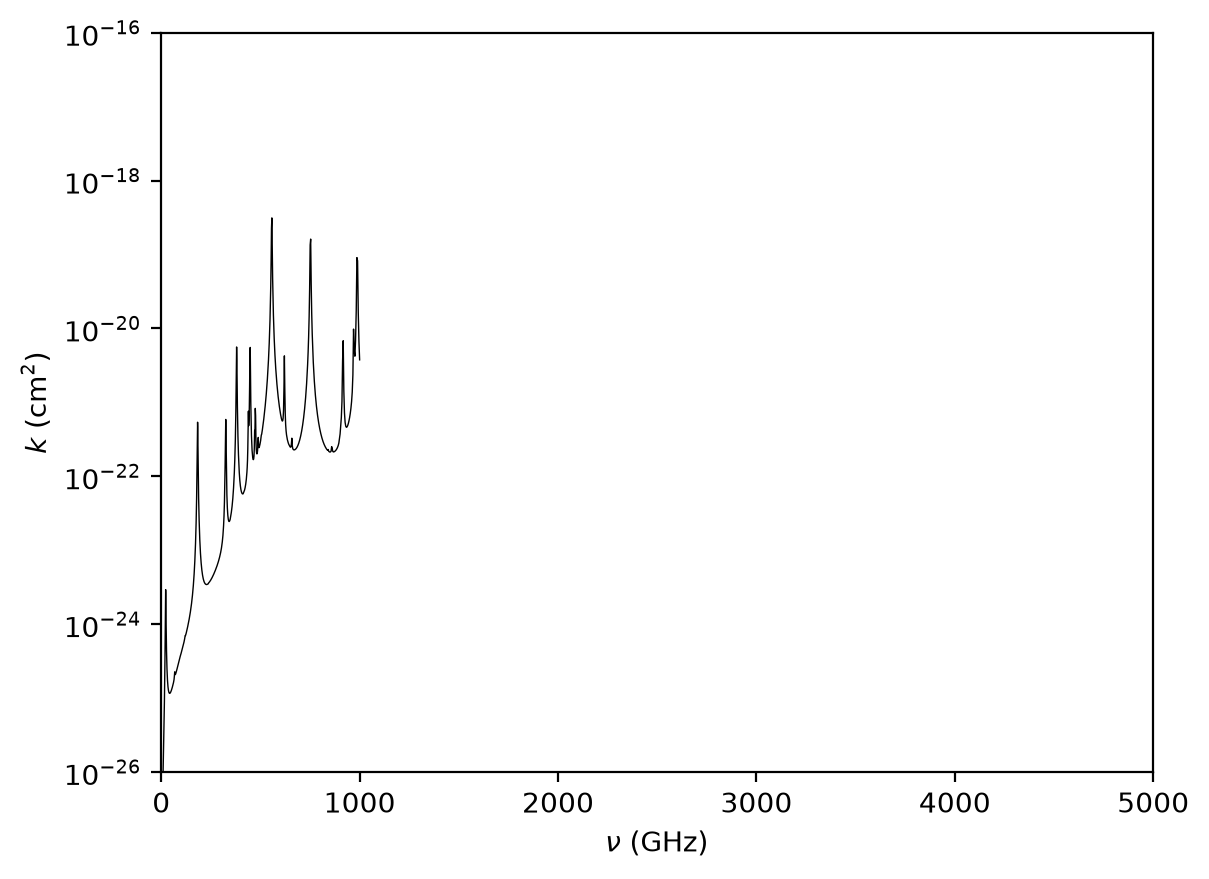

In [4]:
k_line = wve.water_line_absorption(freq_GHz, T, P_hPa, P_water_hPa)
plt.figure(dpi=200)
plt.semilogy(freq_GHz, k_line, 'k-', lw=0.5)
plt.xlabel(r'$\nu$ (GHz)')
plt.ylabel(r'$k$ (cm${}^2$)')
plt.xlim(0,5000)
plt.ylim(1e-26, 1e-16)

## Continuum Absorption

`water_continuum_absorption` returns binary absorption coefficients $(k_{\rm self}, k_{\rm air})$ in $\mathrm{cm}^5$.
The corresponding volume absorption coefficient is:

$$\sigma_{\rm cont}(\nu) = n_{\rm H_2O}^2\,k_{\rm self}(\nu) + n_{\rm H_2O}\,n_{\rm air}\,k_{\rm air}(\nu) \quad [\mathrm{cm}^{-1}]$$

(1e-42, 1e-38)

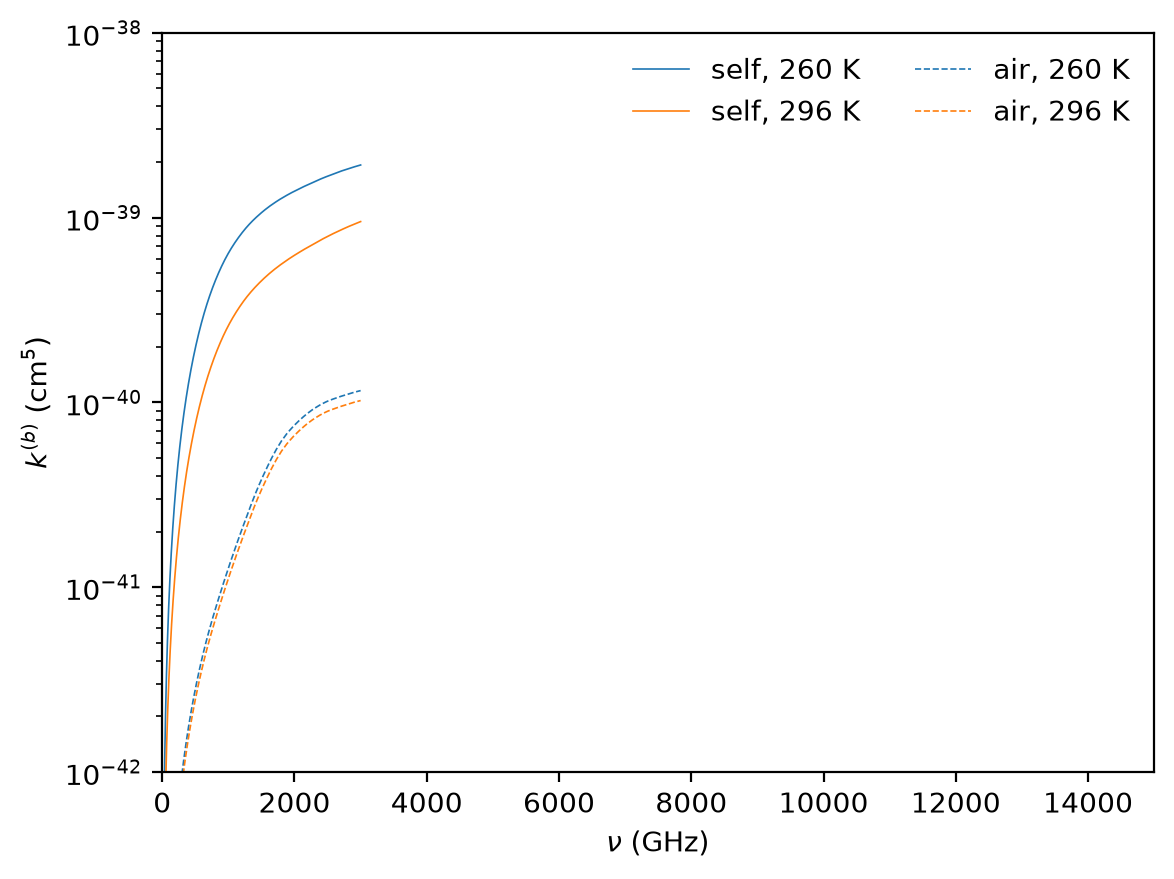

In [5]:
T1 = 260 # K
T2 = 296 # K

freq_GHz = jnp.logspace(jnp.log10(1.0), jnp.log10(3000.0), 2000)

k1_self_cm5, k1_air_cm5 = wve.water_continuum_absorption(freq_GHz, T1)
k2_self_cm5, k2_air_cm5 = wve.water_continuum_absorption(freq_GHz, T2)

plt.figure(dpi=200)
plt.semilogy(freq_GHz, k1_self_cm5, '-', lw=0.6, c='C0', label=f'self, {int(T1)} K')
plt.semilogy(freq_GHz, k2_self_cm5, '-', lw=0.6, c='C1', label=f'self, {int(T2)} K')
plt.semilogy(freq_GHz, k1_air_cm5, '--', lw=0.6, c='C0', label=f'air, {int(T1)} K')
plt.semilogy(freq_GHz, k2_air_cm5, '--', lw=0.6, c='C1', label=f'air, {int(T2)} K')
plt.legend(loc='best', frameon=False, ncols=2)
plt.xlabel(r'$\nu$ (GHz)')
plt.ylabel(r'$k^{(b)}$ (cm${}^5$)')
plt.xlim(0,15000)
plt.ylim(1e-42, 1e-38)

## Plot

In [6]:
freq_GHz = jnp.logspace(jnp.log10(1.0), jnp.log10(1000.0), 2000)

k_line = wve.water_line_absorption(freq_GHz, T, P_hPa, P_water_hPa)
sigma_line = n_H2O_cm3 * k_line

k_self_cm5, k_air_cm5 = wve.water_continuum_absorption(freq_GHz, T)

sigma_self = n_H2O_cm3 * n_H2O_cm3 * k_self_cm5
sigma_air  = n_H2O_cm3 * n_air * k_air_cm5

sigma_cont = sigma_self + sigma_air
sigma_total  = sigma_line + sigma_cont

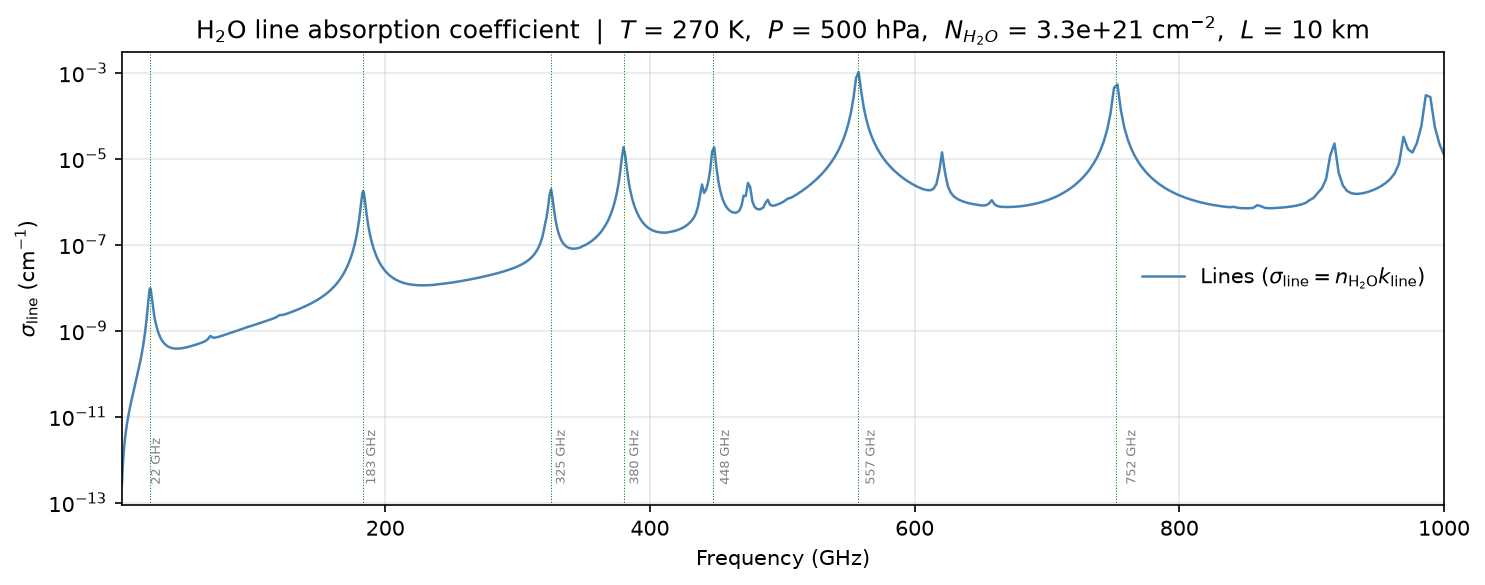

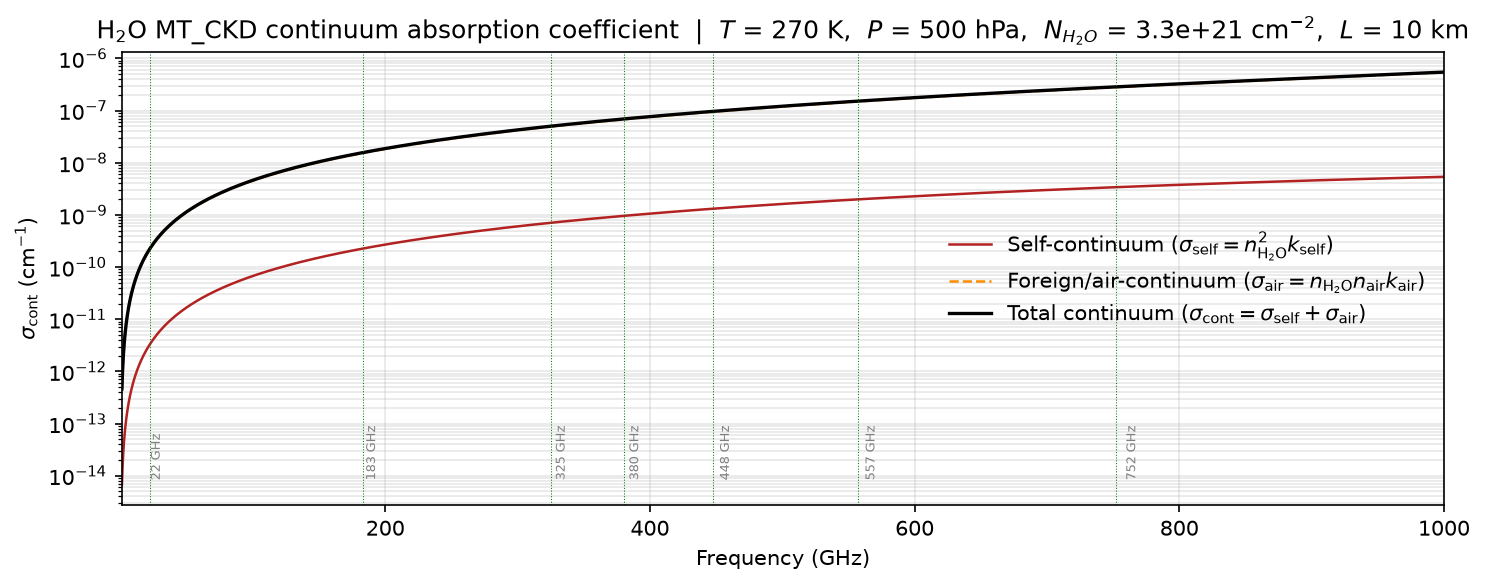

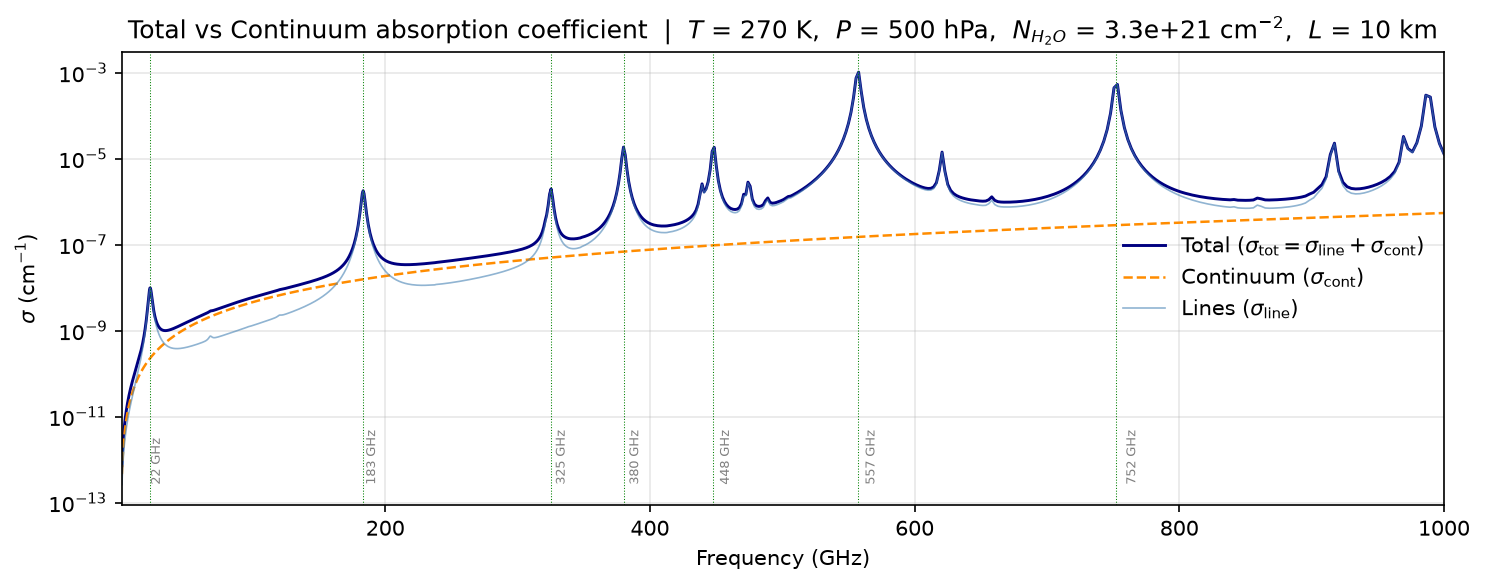

In [7]:
h2o_lines_GHz = [22.235, 183.310, 325.153, 380.197, 448.001, 556.936, 752.033]

def mark_lines(ax):
    ylo = ax.get_ylim()[0]
    for nu0 in h2o_lines_GHz:
        ax.axvline(nu0, color='g', lw=0.5, linestyle=':')
        ax.text(nu0 * 1.01, ylo * 3, f'{nu0:.0f} GHz', fontsize=6,
                rotation=90, va='bottom', ha='left', color='grey')

state_str = (fr'$T$ = {T:.0f} K,  $P$ = {P_hPa:.0f} hPa,  '
             fr'$N_{{H_2O}}$ = {N_H2O_cm2:.1e} cm$^{{-2}}$,  '
             fr'$L$ = {layer_km:.0f} km')

# ── Figure 1: Line absorption ─────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 4), dpi=150)

ax1.semilogy(freq_GHz, np.array(sigma_line), lw=1.2, color='steelblue',
             label=r'Lines ($\sigma_{\rm line} = n_{\rm H_2O} k_{\rm line}$)')
mark_lines(ax1)
ax1.set_xlabel('Frequency (GHz)')
ax1.set_ylabel(r'$\sigma_{\rm line}\ (\mathrm{cm}^{-1})$')
ax1.set_title(fr'H$_2$O line absorption coefficient  |  {state_str}')
ax1.set_xlim(1, 1000)
ax1.legend(frameon=False)
ax1.grid(True, which='both', alpha=0.3)
fig1.tight_layout()
plt.show()

# ── Figure 2: Continuum absorption (self, air, cont) ───────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 4), dpi=150)

ax2.semilogy(freq_GHz, np.array(sigma_self), lw=1.2, color='firebrick',
             label=r'Self-continuum ($\sigma_{\rm self} = n_{\rm H_2O}^2 k_{\rm self}$)')
ax2.semilogy(freq_GHz, np.array(sigma_air),  lw=1.2, color='darkorange',
             linestyle='--',
             label=r'Foreign/air-continuum ($\sigma_{\rm air} = n_{\rm H_2O} n_{\rm air} k_{\rm air}$)')
ax2.semilogy(freq_GHz, np.array(sigma_cont), lw=1.6, color='k',
             label=r'Total continuum ($\sigma_{\rm cont} = \sigma_{\rm self} + \sigma_{\rm air}$)')
mark_lines(ax2)
ax2.set_xlabel('Frequency (GHz)')
ax2.set_ylabel(r'$\sigma_{\rm cont}\ (\mathrm{cm}^{-1})$')
ax2.set_title(fr'H$_2$O MT_CKD continuum absorption coefficient  |  {state_str}')
ax2.set_xlim(1, 1000)
ax2.legend(frameon=False)
ax2.grid(True, which='both', alpha=0.3)
fig2.tight_layout()
plt.show()

# ── Figure 3: Total vs Continuum absorption ───────────────────────────────
fig3, ax3 = plt.subplots(figsize=(10, 4), dpi=150)

ax3.semilogy(freq_GHz, np.array(sigma_total), lw=1.4, color='navy',
             label=r'Total ($\sigma_{\rm tot} = \sigma_{\rm line} + \sigma_{\rm cont}$)')
ax3.semilogy(freq_GHz, np.array(sigma_cont), lw=1.2, color='darkorange',
             linestyle='--', label=r'Continuum ($\sigma_{\rm cont}$)')
ax3.semilogy(freq_GHz, np.array(sigma_line), lw=0.8, color='steelblue',
             alpha=0.6, label=r'Lines ($\sigma_{\rm line}$)')
mark_lines(ax3)
ax3.set_xlabel('Frequency (GHz)')
ax3.set_ylabel(r'$\sigma\ (\mathrm{cm}^{-1})$')
ax3.set_title(fr'Total vs Continuum absorption coefficient  |  {state_str}')
ax3.set_xlim(1, 1000)
ax3.legend(frameon=False)
ax3.grid(True, which='both', alpha=0.3)
fig3.tight_layout()
plt.show()

## Peak Values at Known H₂O Lines

In [22]:
freq_np = np.array(freq_GHz)

header = (f"{'Line (GHz)':>12}  {'σ_total (cm⁻¹)':>16}  "
          f"{'σ_line (cm⁻¹)':>15}  {'σ_self (cm⁻¹)':>15}  {'σ_air (cm⁻¹)':>15}")
print(header)
print("-" * len(header))
for nu0 in h2o_lines_GHz:
    idx = np.argmin(np.abs(freq_np - nu0))
    print(f"{nu0:>12.3f}  "
          f"{float(sigma_total[idx]):>16.3e}  "
          f"{float(sigma_line[idx]):>15.3e}  "
          f"{float(sigma_self[idx]):>15.3e}  "
          f"{float(sigma_air[idx]):>15.3e}")

  Line (GHz)    σ_total (cm⁻¹)    σ_line (cm⁻¹)    σ_self (cm⁻¹)     σ_air (cm⁻¹)
---------------------------------------------------------------------------------
      22.235         1.031e-08        1.008e-08        3.349e-12        2.252e-10
     183.310         1.840e-06        1.825e-06        2.259e-10        1.551e-08
     325.153         2.022e-06        1.971e-06        7.059e-10        4.959e-08
     380.197         1.943e-05        1.936e-05        9.535e-10        6.816e-08
     448.001         1.838e-05        1.828e-05        1.311e-09        9.583e-08
     556.936         1.033e-03        1.033e-03        1.984e-09        1.502e-07
     752.033         5.345e-04        5.342e-04        3.389e-09        2.847e-07
